# EDA - GiveMeSomeCredit Training Dataset
## Análisis Exploratorio de Datos - cs-training.csv

## 1. Importación de Librerías

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

# Configurar estilo
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (14, 6)
plt.rcParams['font.size'] = 10

## 2. Carga de Datos

In [2]:
import os
p = 'data/GiveMeSomeCredit/cs-training.csv'
if os.path.exists(p):
    df = pd.read_csv(p, index_col=0)
    print(f"Dataset cargado: {df.shape[0]:,} filas × {df.shape[1]} columnas")
    print(f"\nPrimeras filas:")
    df.head()
else:
    print(f'File not found: {p}. Skipping load.')
    df = pd.DataFrame()

Dataset cargado: 150,000 filas × 11 columnas

Primeras filas:


## 3. Información General

In [3]:
print("Info del dataset:")
df.info()
print("\n" + "="*80 + "\n")
print("Estadísticas descriptivas:")
df.describe()

Info del dataset:
<class 'pandas.DataFrame'>
RangeIndex: 150000 entries, 1 to 150000
Data columns (total 11 columns):
 #   Column                                Non-Null Count   Dtype  
---  ------                                --------------   -----  
 0   SeriousDlqin2yrs                      150000 non-null  int64  
 1   RevolvingUtilizationOfUnsecuredLines  150000 non-null  float64
 2   age                                   150000 non-null  int64  
 3   NumberOfTime30-59DaysPastDueNotWorse  150000 non-null  int64  
 4   DebtRatio                             150000 non-null  float64
 5   MonthlyIncome                         120269 non-null  float64
 6   NumberOfOpenCreditLinesAndLoans       150000 non-null  int64  
 7   NumberOfTimes90DaysLate               150000 non-null  int64  
 8   NumberRealEstateLoansOrLines          150000 non-null  int64  
 9   NumberOfTime60-89DaysPastDueNotWorse  150000 non-null  int64  
 10  NumberOfDependents                    146076 non-null  float6

,SeriousDlqin2yrs,RevolvingUtilizationOfUnsecuredLines,age,NumberOfTime30-59DaysPastDueNotWorse,DebtRatio,MonthlyIncome,NumberOfOpenCreditLinesAndLoans,NumberOfTimes90DaysLate,NumberRealEstateLoansOrLines,NumberOfTime60-89DaysPastDueNotWorse,NumberOfDependents
count,150000.000000,150000.000000,150000.000000,150000.000000,150000.000000,1.202690e+05,150000.000000,150000.000000,150000.000000,150000.000000,146076.000000
mean,0.066840,6.048438,52.295207,0.421033,353.005076,6.670221e+03,8.452760,0.265973,1.018240,0.240387,0.757222
std,0.249746,249.755371,14.771866,4.192781,2037.818523,1.438467e+04,5.145951,4.169304,1.129771,4.155179,1.115086
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000e+00,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.000000,0.029867,41.000000,0.000000,0.175074,3.400000e+03,5.000000,0.000000,0.000000,0.000000,0.000000
50%,0.000000,0.154181,52.000000,0.000000,0.366508,5.400000e+03,8.000000,0.000000,1.000000,0.000000,0.000000
75%,0.000000,0.559046,63.000000,0.000000,0.868254,8.249000e+03,11.000000,0.000000,2.000000,0.000000,1.000000
max,1.000000,50708.000000,109.000000,98.000000,329664.000000,3.008750e+06,58.000000,98.000000,54.000000,98.000000,20.000000


## 4. Análisis de Valores Faltantes

Valores faltantes:
                    Faltantes  Porcentaje
MonthlyIncome           29731   19.820667
NumberOfDependents       3924    2.616000


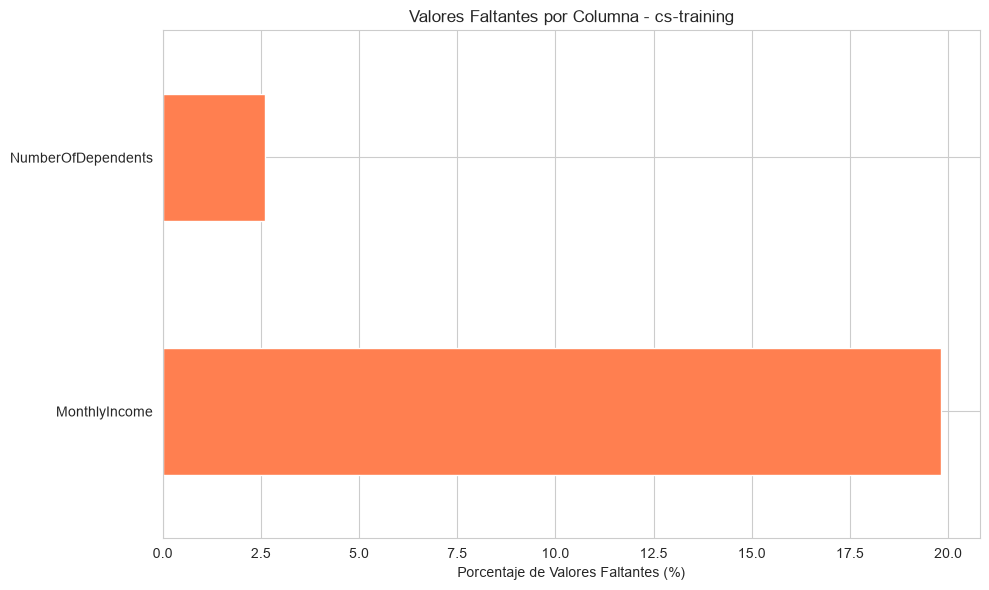

In [4]:
# Valores faltantes
missing = df.isnull().sum()
missing_percent = (missing / len(df)) * 100
missing_df = pd.DataFrame({'Faltantes': missing, 'Porcentaje': missing_percent})
missing_df = missing_df[missing_df['Faltantes'] > 0].sort_values('Faltantes', ascending=False)

print("Valores faltantes:")
print(missing_df)

# Gráfico de valores faltantes
if len(missing_df) > 0:
    fig, ax = plt.subplots(figsize=(10, 6))
    missing_df['Porcentaje'].plot(kind='barh', ax=ax, color='coral')
    ax.set_xlabel('Porcentaje de Valores Faltantes (%)')
    ax.set_title('Valores Faltantes por Columna - cs-training')
    plt.tight_layout()
    plt.show()
else:
    print("No hay valores faltantes en el dataset")

## 5. Distribución de la Variable Objetivo

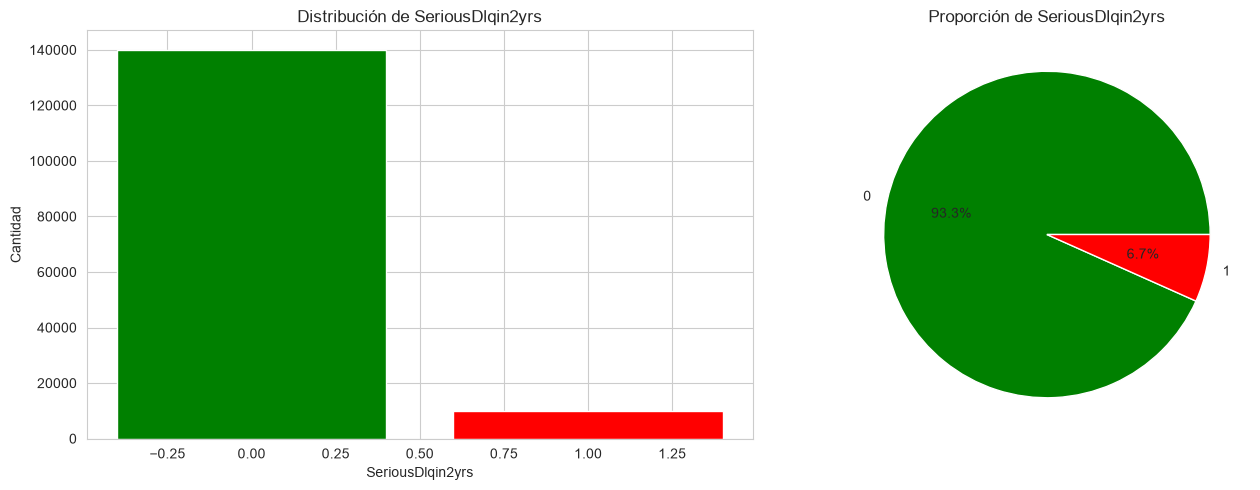

Distribución de SeriousDlqin2yrs:
SeriousDlqin2yrs
0    139974
1     10026
Name: count, dtype: int64

Porcentajes:
SeriousDlqin2yrs
0    93.316
1     6.684
Name: count, dtype: float64


In [5]:
# Variable objetivo (generalmente la primera o última columna)
target_col = df.columns[0]  # Primera columna suele ser la variable objetivo

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Conteo
target_counts = df[target_col].value_counts()
axes[0].bar(target_counts.index, target_counts.values, color=['green', 'red'])
axes[0].set_title(f'Distribución de {target_col}')
axes[0].set_xlabel(target_col)
axes[0].set_ylabel('Cantidad')

# Porcentaje
axes[1].pie(target_counts.values, labels=[f'{int(val)}' for val in target_counts.index], 
            autopct='%1.1f%%', colors=['green', 'red'])
axes[1].set_title(f'Proporción de {target_col}')

plt.tight_layout()
plt.show()

print(f"Distribución de {target_col}:")
print(target_counts)
print(f"\nPorcentajes:")
print(target_counts / len(df) * 100)

## 6. Análisis por Tipo de Variable

In [6]:
# Separar variables numéricas y categóricas
numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
categorical_cols = df.select_dtypes(include=['object']).columns.tolist()

print(f"Columnas numéricas ({len(numeric_cols)}): {numeric_cols}")
print(f"\nColumnas categóricas ({len(categorical_cols)}): {categorical_cols}")

Columnas numéricas (11): ['SeriousDlqin2yrs', 'RevolvingUtilizationOfUnsecuredLines', 'age', 'NumberOfTime30-59DaysPastDueNotWorse', 'DebtRatio', 'MonthlyIncome', 'NumberOfOpenCreditLinesAndLoans', 'NumberOfTimes90DaysLate', 'NumberRealEstateLoansOrLines', 'NumberOfTime60-89DaysPastDueNotWorse', 'NumberOfDependents']

Columnas categóricas (0): []


## 7. Distribuciones de Variables Numéricas

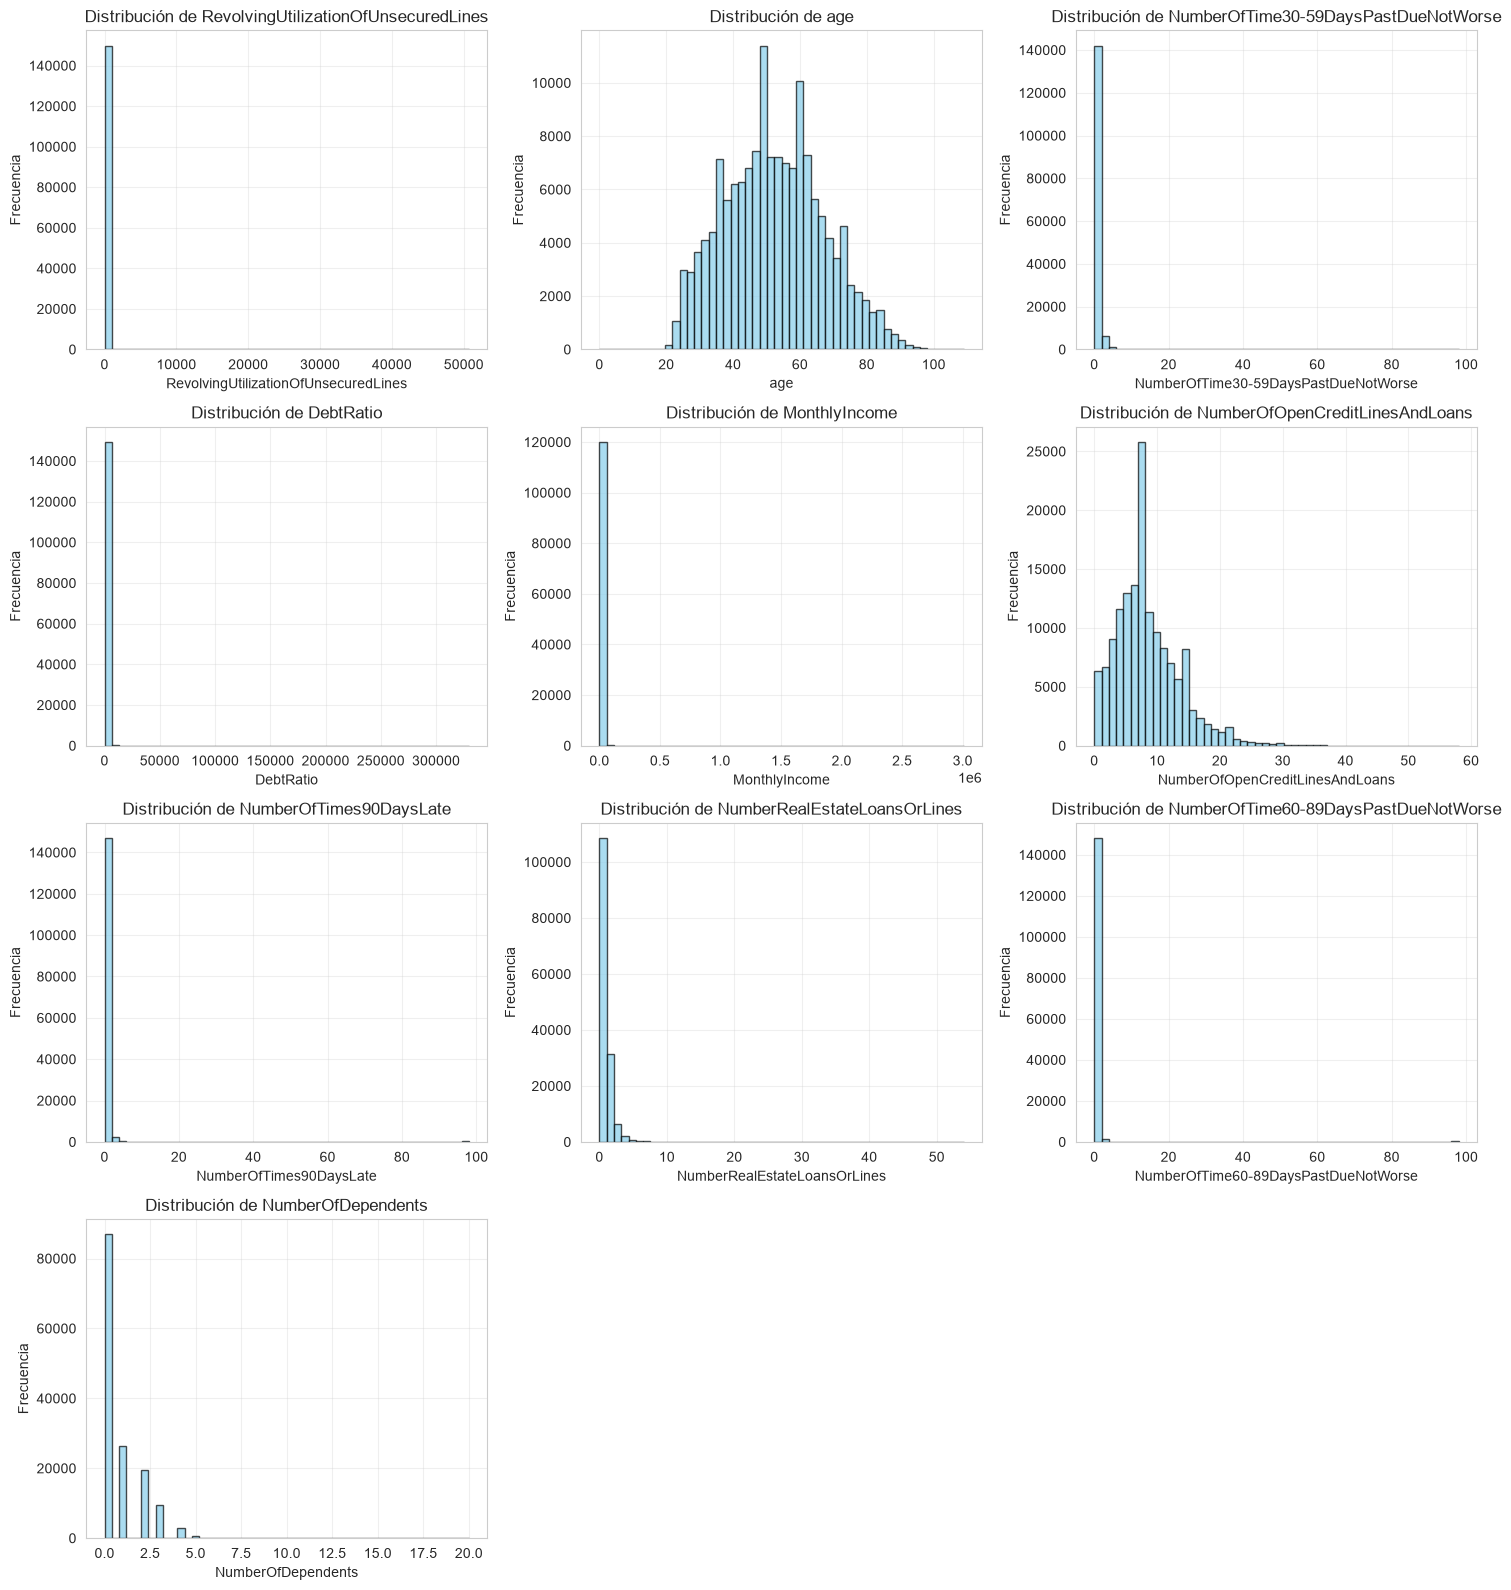

In [7]:
# Histogramas de variables numéricas
numeric_cols_clean = [col for col in numeric_cols if col != target_col]

if numeric_cols_clean:
    n_cols = min(3, len(numeric_cols_clean))
    n_rows = (len(numeric_cols_clean) + n_cols - 1) // n_cols
    
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(15, 4*n_rows))
    axes = axes.flatten() if n_rows > 1 or n_cols > 1 else [axes]
    
    for idx, col in enumerate(numeric_cols_clean[:len(axes)]):
        axes[idx].hist(df[col].dropna(), bins=50, edgecolor='black', alpha=0.7, color='skyblue')
        axes[idx].set_title(f'Distribución de {col}')
        axes[idx].set_xlabel(col)
        axes[idx].set_ylabel('Frecuencia')
        axes[idx].grid(alpha=0.3)
    
    # Ocultar ejes no usados
    for idx in range(len(numeric_cols_clean), len(axes)):
        axes[idx].set_visible(False)
    
    plt.tight_layout()
    plt.show()

## 8. Estadísticas de Correlación

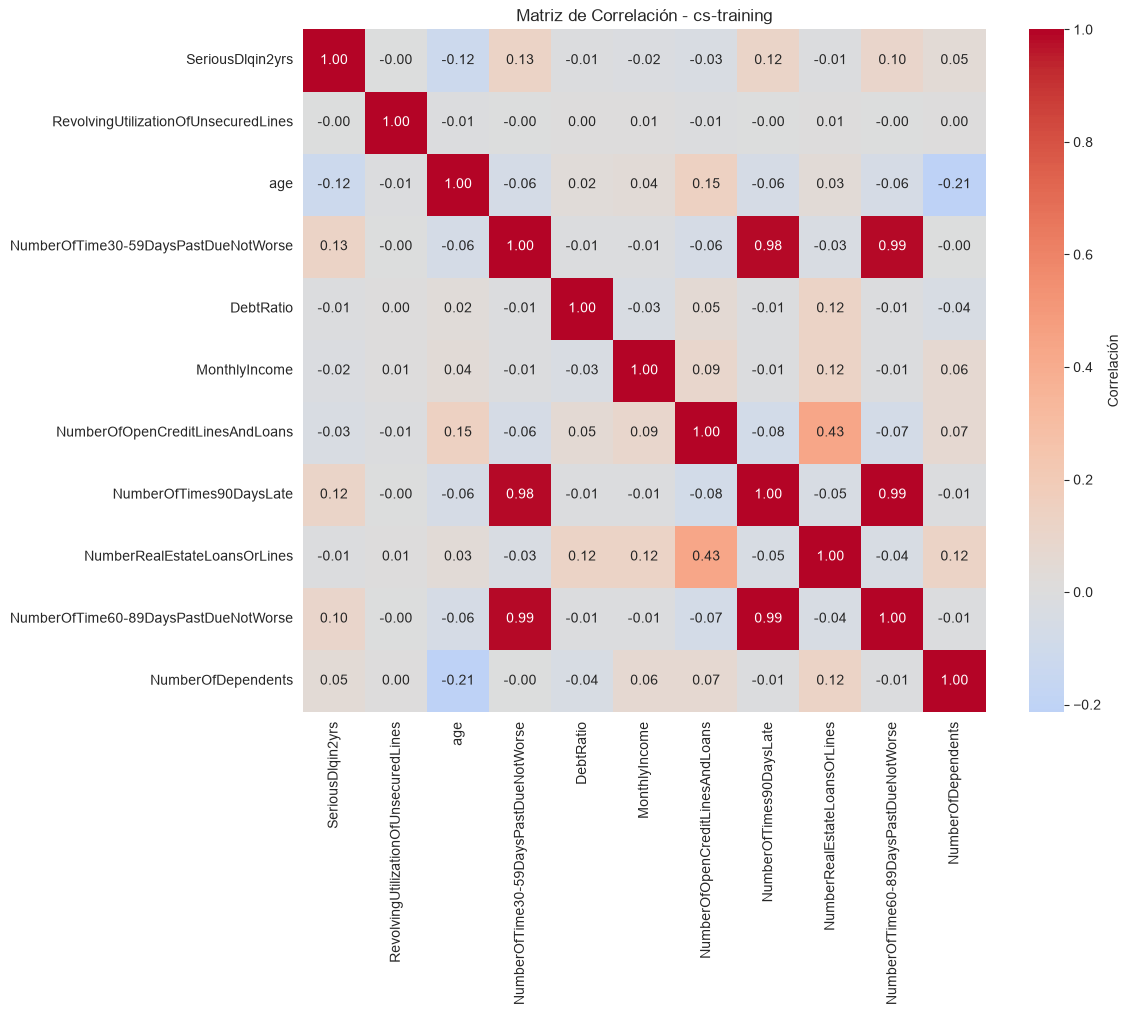


Correlaciones más altas con la variable objetivo:
SeriousDlqin2yrs                        1.000000
NumberOfTime30-59DaysPastDueNotWorse    0.125587
NumberOfTimes90DaysLate                 0.117175
NumberOfTime60-89DaysPastDueNotWorse    0.102261
NumberOfDependents                      0.046048
RevolvingUtilizationOfUnsecuredLines   -0.001802
NumberRealEstateLoansOrLines           -0.007038
DebtRatio                              -0.007602
MonthlyIncome                          -0.019746
NumberOfOpenCreditLinesAndLoans        -0.029669
Name: SeriousDlqin2yrs, dtype: float64


In [8]:
# Matriz de correlación
correlation_matrix = df[numeric_cols].corr()

# Heatmap
plt.figure(figsize=(12, 10))
sns.heatmap(correlation_matrix, annot=True, fmt='.2f', cmap='coolwarm', center=0, 
            cbar_kws={'label': 'Correlación'}, square=True)
plt.title('Matriz de Correlación - cs-training')
plt.tight_layout()
plt.show()

print("\nCorrelaciones más altas con la variable objetivo:")
if target_col in correlation_matrix.columns:
    target_corr = correlation_matrix[target_col].sort_values(ascending=False)
    print(target_corr.head(10))

## 9. Detección de Outliers

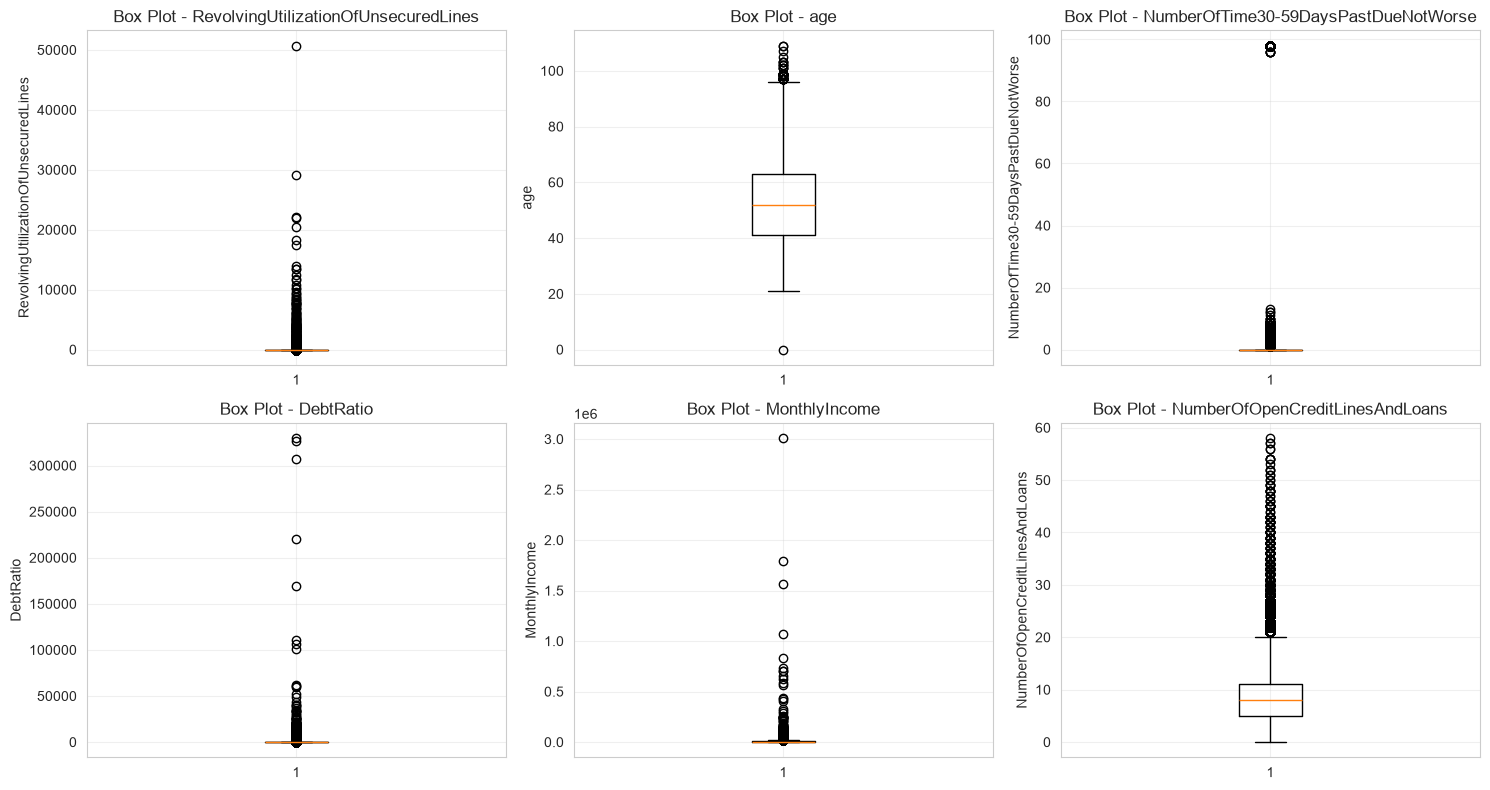

In [9]:
# Box plots para detectar outliers
numeric_cols_clean = [col for col in numeric_cols if col != target_col][:6]  # Primeras 6

fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.flatten()

for idx, col in enumerate(numeric_cols_clean):
    axes[idx].boxplot(df[col].dropna(), vert=True)
    axes[idx].set_title(f'Box Plot - {col}')
    axes[idx].set_ylabel(col)
    axes[idx].grid(alpha=0.3)

plt.tight_layout()
plt.show()

## 10. Resumen de Hallazgos

In [10]:
print("=" * 80)
print("RESUMEN - DATASET cs-training.csv")
print("=" * 80)
print(f"\n📊 Tamaño del dataset: {df.shape[0]:,} filas × {df.shape[1]} columnas")
print(f"\n📈 Variables numéricas: {len(numeric_cols)}")
print(f"📂 Variables categóricas: {len(categorical_cols)}")
print(f"\n❌ Filas con valores faltantes: {df.isnull().any(axis=1).sum():,}")
print(f"\n✅ Filas completas: {len(df) - df.isnull().any(axis=1).sum():,}")
print("\n" + "=" * 80)

RESUMEN - DATASET cs-training.csv

📊 Tamaño del dataset: 150,000 filas × 11 columnas

📈 Variables numéricas: 11
📂 Variables categóricas: 0

❌ Filas con valores faltantes: 29,731

✅ Filas completas: 120,269

